In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 100) # помогает вывести больше колонок без сжатия

# Функции

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Оценивает классификационную модель по множеству метрик на трейне и тесте,
    строит один общий ROC-кривой график и возвращает сводную таблицу метрик.

    Args:
        model: Обученная модель, реализующая методы `predict` и `predict_proba`.
        X_train (pd.DataFrame or np.ndarray): Признаки обучающей выборки.
        y_train (pd.Series or np.ndarray): Целевая переменная обучающей выборки.
        X_test (pd.DataFrame or np.ndarray): Признаки тестовой выборки.
        y_test (pd.Series or np.ndarray): Целевая переменная тестовой выборки.

    Returns:
        pd.DataFrame: Таблица метрик для трейна и теста с колонками:
                      ['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'].

    """
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Предсказания вероятностей для ROC AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    metrics = {
        'Dataset': ['Train', 'Test'],
        'Accuracy': [
            accuracy_score(y_train, y_train_pred),
            accuracy_score(y_test, y_test_pred)
        ],
        'Precision': [
            precision_score(y_train, y_train_pred),
            precision_score(y_test, y_test_pred)
        ],
        'Recall': [
            recall_score(y_train, y_train_pred),
            recall_score(y_test, y_test_pred)
        ],
        'F1 Score': [
            f1_score(y_train, y_train_pred),
            f1_score(y_test, y_test_pred)
        ],
        'ROC AUC': [
            roc_auc_score(y_train, y_train_proba),
            roc_auc_score(y_test, y_test_proba)
        ]
    }

    results_df = pd.DataFrame(metrics)

    # ROC-кривая
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, label=f'Train ROC AUC = {metrics["ROC AUC"][0]:.3f}', linestyle='--')
    plt.plot(fpr_test, tpr_test, label=f'Test ROC AUC = {metrics["ROC AUC"][1]:.3f}', linestyle='-')
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Train vs Test')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results_df


# Загрузка данных

https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data

описание данных https://www.sciencedirect.com/science/article/pii/S2352340918315191

In [4]:
try:
  df = pd.read_csv("hotel_bookings.csv")
except:
  df = pd.read_csv("https://drive.google.com/uc?id=1H1YQexjDN7Ud_rOmjVx0kFzuWBxuTAwl")


In [8]:
df.head(100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Resort Hotel,1,72,2015,July,27,3,0,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,73.80,0,1,Canceled,2015-06-29
96,Resort Hotel,1,63,2015,July,27,3,2,5,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,242.0,NaN,0,Transient,117.00,0,1,Canceled,2015-05-13
97,Resort Hotel,0,63,2015,July,27,3,2,5,3,0.0,0,HB,ESP,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,105.0,NaN,0,Transient,196.54,0,1,Check-Out,2015-07-10
98,Resort Hotel,0,101,2015,July,27,3,2,5,2,1.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,99.30,1,2,Check-Out,2015-07-10


In [6]:
target = "is_canceled" # пробуем предсказать будут ли отмены бронирования

# Разделение на X и y
X_full = df.drop(columns=[target])
y = df[target]

# Определим числовые и категориальные признаки
num_cols = X_full.select_dtypes(include="number").columns.tolist()
cat_cols = X_full.select_dtypes(include="object").columns.tolist()

In [7]:
num_cols

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

признак Company	- Categorical	ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

признак Agent - Categorical	ID of the travel agency that made the bookinga

исключим

In [9]:
num_cols.remove('company')
cat_cols.append('company')

In [10]:
num_cols.remove('agent')
cat_cols.append('agent')

In [11]:
# год прилета скорее всего никогда уже не повторится, кажется, что его влияние будет непредсказуемо влиять на результат
num_cols.remove('arrival_date_year')
cat_cols.append('arrival_date_year')

In [12]:
cat_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date',
 'company',
 'agent',
 'arrival_date_year']

><font color='orange'> категориальные признаки пока исключаем их из последюущего анализа

In [13]:
X_full = X_full[num_cols].copy()

In [14]:
X_full

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,342,27,1,0,0,2,0.0,0,0,0,0,3,0,0.00,0,0
1,737,27,1,0,0,2,0.0,0,0,0,0,4,0,0.00,0,0
2,7,27,1,0,1,1,0.0,0,0,0,0,0,0,75.00,0,0
3,13,27,1,0,1,1,0.0,0,0,0,0,0,0,75.00,0,0
4,14,27,1,0,2,2,0.0,0,0,0,0,0,0,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,23,35,30,2,5,2,0.0,0,0,0,0,0,0,96.14,0,0
119386,102,35,31,2,5,3,0.0,0,0,0,0,0,0,225.43,0,2
119387,34,35,31,2,5,2,0.0,0,0,0,0,0,0,157.71,0,4
119388,109,35,31,2,5,2,0.0,0,0,0,0,0,0,104.40,0,0


# <font color='green'>EDA

In [15]:
# === Общая информация ===
print("Размерность датасета:", X_full.shape)
print("\nТипы данных:")
print(X_full.dtypes.value_counts())

Размерность датасета: (119390, 16)

Типы данных:
int64      14
float64     2
Name: count, dtype: int64



Распределение target (is_canceled):
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


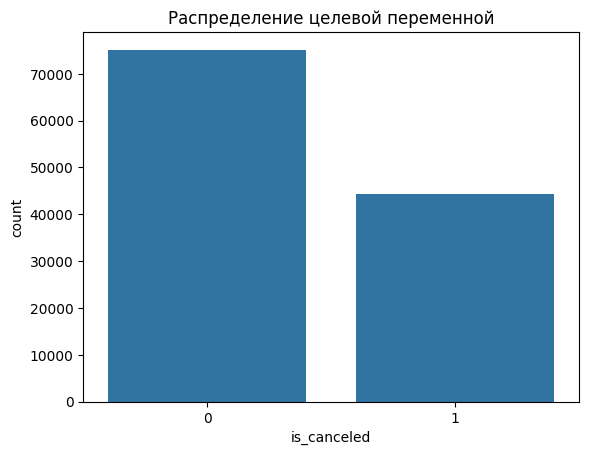

In [16]:
# === Распределение целевой переменной ===
print("\nРаспределение target (is_canceled):")
print(df["is_canceled"].value_counts(normalize=True))
sns.countplot(x="is_canceled", data=df)
plt.title("Распределение целевой переменной")
plt.show()

это важный момент! потому что если есть сильный перекос в распределении таргет переменной - то нужно подумать что с этим делать!  
как то снизить дисбаланс.   
а вдруг распределение двумодальное?

In [26]:
# === Пропуски ===
missing = X_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nПризнаки с пропусками:")
print(missing)


Признаки с пропусками:
children    4
dtype: int64


In [18]:
# описание данных
X_full[num_cols].describe().T.sort_values("std", ascending=False)

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
total_of_special_requests,119390.0,0.571363,0.792798,0.00,0.00,0.000,1.0,5.0


<Axes: xlabel='lead_time', ylabel='Count'>

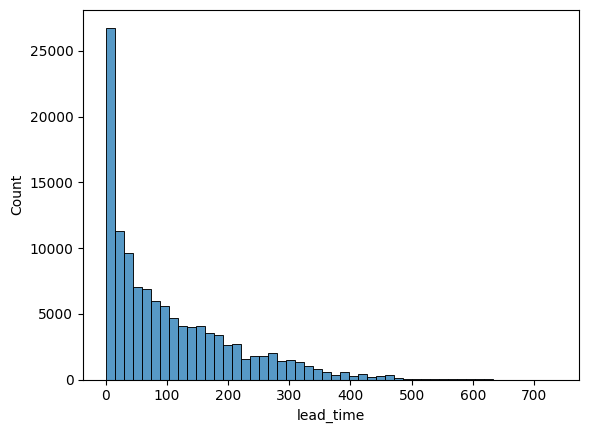

In [19]:
sns.histplot(X_full['lead_time'], bins=50)

<Axes: xlabel='adults', ylabel='Count'>

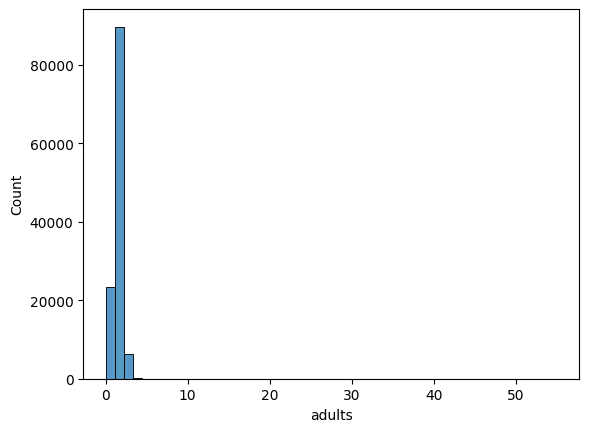

In [20]:
sns.histplot(X_full['adults'], bins=50)

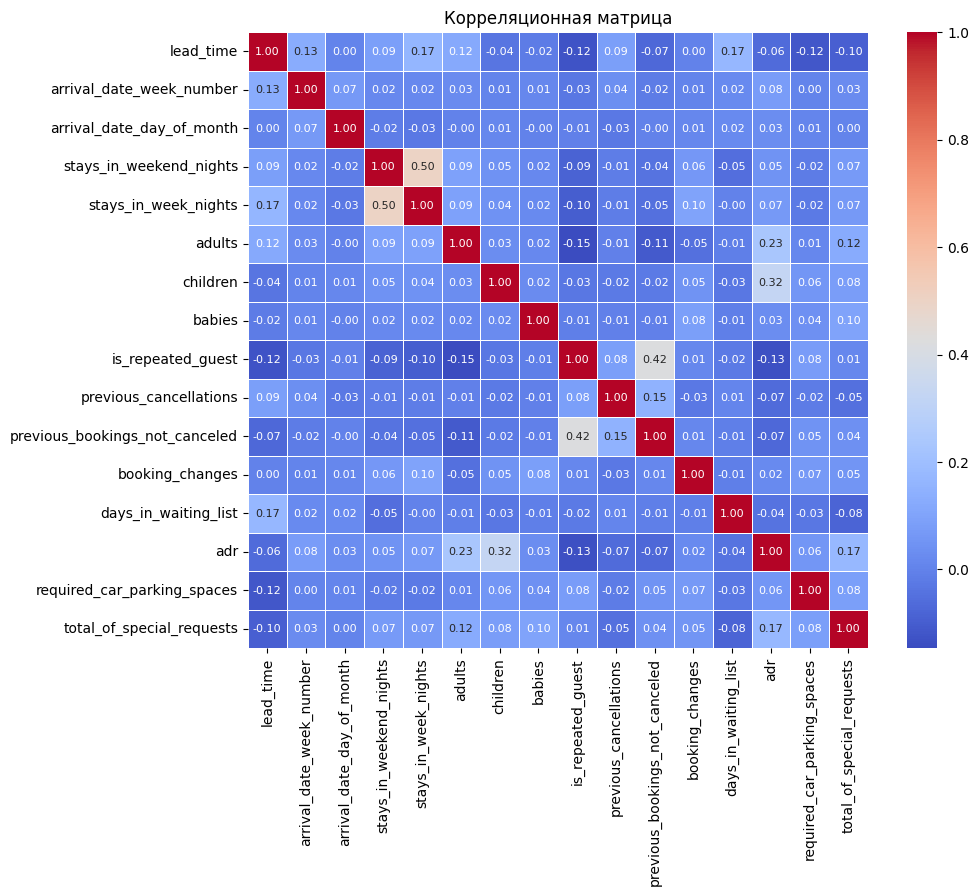

In [21]:
# Корреляция
plt.figure(figsize=(10, 8))
corr = X_full.corr()
sns.heatmap(corr, annot=True, fmt='.2f',annot_kws={'size':8}, cmap="coolwarm", linewidths=0.5, cbar=True)
plt.title("Корреляционная матрица")
plt.show()

# <font color='green'>деление на трейн и тест

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_full[num_cols], y, test_size=0.2, random_state=42)


In [23]:
X_train.shape

(95512, 16)

# <font color='green'>Подготовка данных для обучения моделей

In [28]:
X_test.isna().sum()

lead_time                         0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
days_in_waiting_list              0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [24]:
# ============ Импутация ============
# Числовые — среднее
num_imputer = SimpleImputer(strategy="mean")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [29]:
# ============ Удаление низкой дисперсии ============
var_thresh = VarianceThreshold(threshold=0.01)
var_thresh.fit_transform(X_train[num_cols])

array([[ 64.  ,  18.  ,   6.  , ..., 189.  ,   0.  ,   0.  ],
       [ 34.  ,  28.  ,  10.  , ..., 146.  ,   0.  ,   0.  ],
       [  8.  ,  39.  ,  24.  , ..., 259.  ,   0.  ,   0.  ],
       ...,
       [ 74.  ,  53.  ,  27.  , ...,  92.65,   0.  ,   0.  ],
       [130.  ,  31.  ,   1.  , ..., 120.6 ,   0.  ,   2.  ],
       [ 16.  ,  31.  ,  31.  , ..., 120.  ,   0.  ,   1.  ]],
      shape=(95512, 15))

In [34]:
var_thresh.get_support()

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True])

In [32]:
removed_features = X_train.columns[~var_thresh.get_support()]
removed_features

Index(['babies'], dtype='object')

In [35]:
X_train_num_filtered = pd.DataFrame(var_thresh.fit_transform(X_train[num_cols]),
                                    columns=np.array(num_cols)[var_thresh.get_support()])
X_test_num_filtered = pd.DataFrame(var_thresh.transform(X_test[num_cols]),
                                   columns=X_train_num_filtered.columns)

In [36]:
X_train_num_filtered.shape

(95512, 15)

Mutual Information (MI) — это мера зависимости между двумя переменными:

Она показывает, насколько хорошо знание одного признака уменьшает неопределённость относительно целевой переменной.

Если признак полностью независим от целевой переменной → MI = 0.

Чем выше MI → тем больше информации этот признак даёт о целевой переменной.

В отличие от корреляции, MI может выявлять как линейные, так и нелинейные зависимости.



In [37]:
mi = mutual_info_classif(
    X_train_num_filtered,  # входные числовые признаки (уже отфильтрованные по дисперсии)
    y_train,               # целевая переменная
    discrete_features='auto',  # автоматически определяет, какие признаки дискретные
    random_state=0         # для воспроизводимости
)
# Функция mutual_info_classif (из sklearn.feature_selection) возвращает массив MI-оценок, по одной на каждый признак.

In [38]:
mi

array([0.07925268, 0.00331704, 0.        , 0.00377387, 0.00971153,
       0.01215475, 0.00033319, 0.00537741, 0.04316834, 0.00766249,
       0.01914365, 0.01489849, 0.07580575, 0.0298691 , 0.03955625])

In [39]:
mi_scores = pd.Series(mi, index=X_train_num_filtered.columns).sort_values(ascending=False)
mi_scores

lead_time                         0.079253
adr                               0.075806
previous_cancellations            0.043168
total_of_special_requests         0.039556
required_car_parking_spaces       0.029869
booking_changes                   0.019144
days_in_waiting_list              0.014898
adults                            0.012155
stays_in_week_nights              0.009712
previous_bookings_not_canceled    0.007662
is_repeated_guest                 0.005377
stays_in_weekend_nights           0.003774
arrival_date_week_number          0.003317
children                          0.000333
arrival_date_day_of_month         0.000000
dtype: float64

In [40]:
# Оставим признаки с информативностью > 0.01
selected_features = mi_scores[mi_scores > 0.01].index.tolist()
X_train_selected = X_train_num_filtered[selected_features]
X_test_selected = X_test_num_filtered[selected_features]

In [41]:
X_train_selected.shape

(95512, 8)

In [42]:
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)


In [43]:
X_train_scaled

array([[-0.37359427,  1.70167635, -0.10276486, ..., -0.33881578,
        -0.13188328,  2.00113523],
       [-0.65435702,  0.8616889 , -0.10276486, ..., -0.33881578,
        -0.13188328,  0.25159128],
       [-0.89768473,  3.06909779, -0.10276486, ..., -0.33881578,
        -0.13188328,  0.25159128],
       ...,
       [-0.28000669, -0.18048158, -0.10276486, ..., -0.33881578,
        -0.13188328,  2.00113523],
       [ 0.24408377,  0.36551027, -0.10276486, ..., -0.33881578,
        -0.13188328,  0.25159128],
       [-0.82281466,  0.35378951, -0.10276486, ..., -0.33881578,
        -0.13188328, -1.49795267]], shape=(95512, 8))

# <font color='green'>Моделирование

In [44]:
# Обучение логистической регрессии
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_selected, y_train)


LogisticRegression(max_iter=1000)

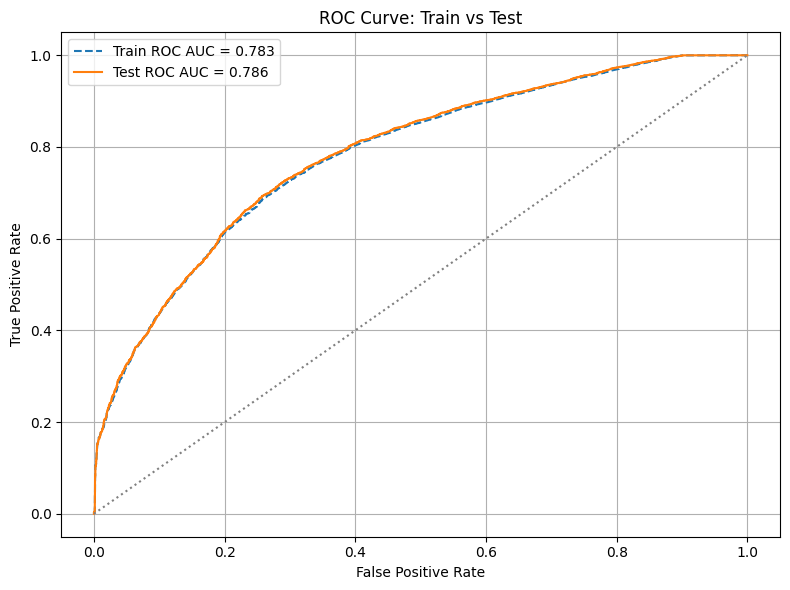

,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Train,0.730830,0.691955,0.487958,0.572322,0.782697
1,Test,0.729291,0.699507,0.489912,0.576242,0.785735


In [45]:
evaluate_model(log_reg, X_train_selected, y_train, X_test_selected, y_test)

Как выбор метрики влияет на модель при несбаллансированных классах?

1) если классы не сбаллансированы, то Accuracy - нет смысла смотреть!
(0) - 990
(1) - 10

строим модель из одних нулей. тогда TP = 0, FP = 0, FN = 10, TN = 990

Итого Acc = 990/1000 -> стремится к 1, а модель явно плохая!

2) в этом случае смотрят на Precision, Recall, F1 Score и ROC AUC

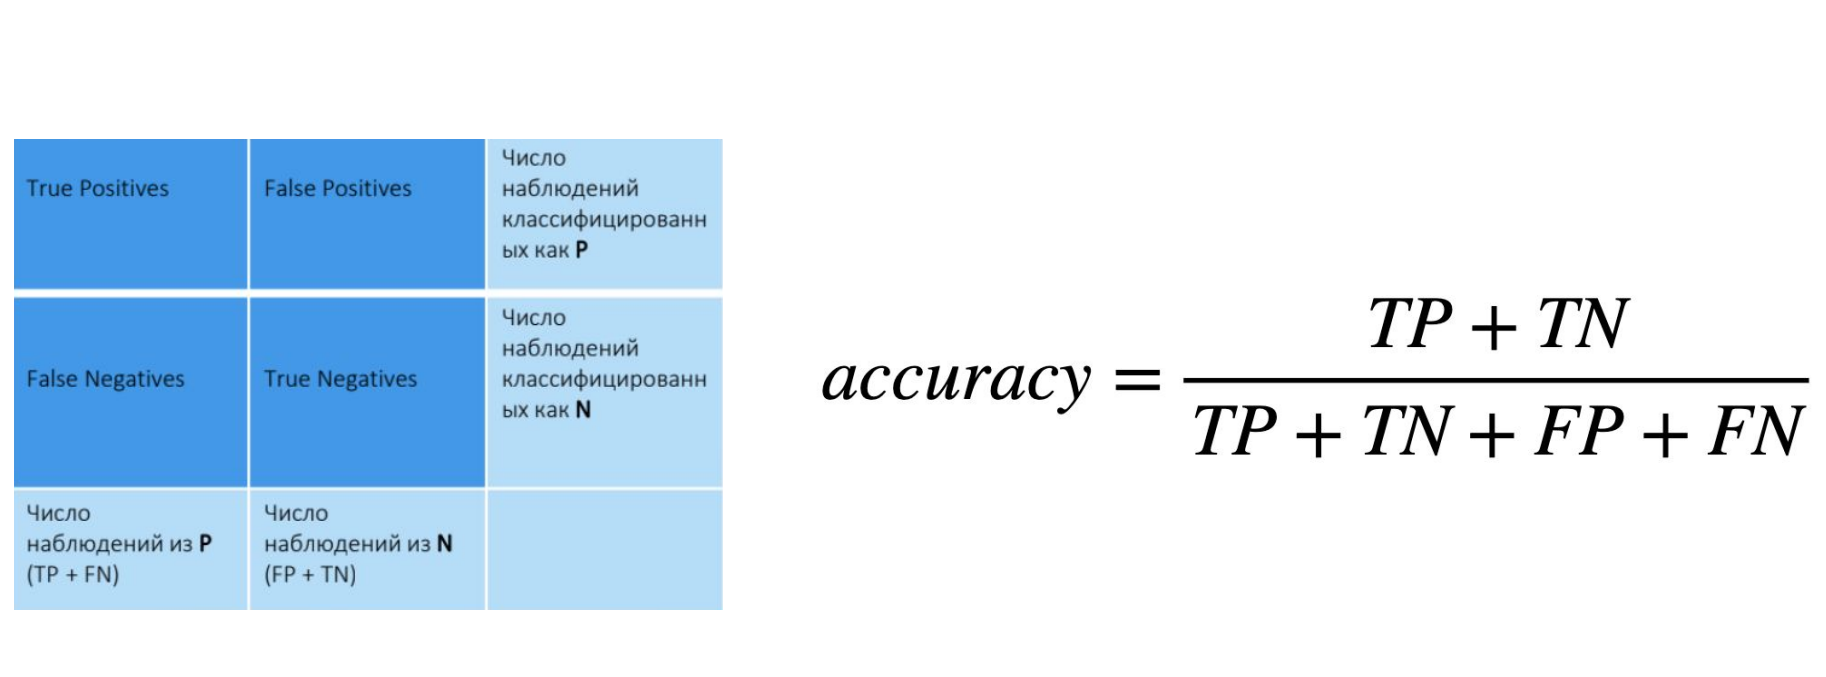

## PCA

n_components='mle' — это способ автоматически подобрать оптимальное количество главных компонент, при котором сохраняется максимальное количество информации, но без избыточных признаков.

In [48]:
X_train.shape

(95512, 16)

In [64]:
# PCA
pca = PCA(n_components='mle' , random_state=42)  # сохраняем 99% дисперсии
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [65]:
pca_df = pd.DataFrame(X_train_pca)
pca_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-43.465784,85.207113,-0.429642,-11.332017,-9.400473,-1.330623,-0.147829,0.972846,0.973590,-0.892361,-0.325966,0.969472,-0.255959,-0.062045,0.032816
1,-71.598871,41.365994,0.105490,0.497383,-6.030937,-1.367906,-0.230244,0.210013,0.381384,-0.725777,-0.117938,0.092520,0.804963,-0.107716,-0.015376
2,-101.772001,153.581748,2.459760,10.111048,6.675552,-1.539094,0.006902,0.028155,0.501916,-1.003536,-0.048800,-0.169583,1.510960,-0.166512,0.019005
3,147.199546,-6.577506,-6.709736,-7.886950,5.930164,1.332216,0.057396,0.674547,0.150100,0.287234,-0.312236,-0.101395,-0.088388,-0.017219,0.006387
4,-78.900416,-62.994854,-0.810618,-17.088084,3.851073,-0.935953,-0.437591,0.634320,0.234525,0.477820,-0.265055,0.213838,0.039971,-0.079348,-0.051678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95507,-100.883141,-28.818358,0.218381,2.600596,-7.821347,-1.615770,3.852564,-1.162077,0.983456,0.011439,0.839928,0.660861,0.022719,0.928290,0.692568
95508,-14.430405,32.341206,-1.622923,-11.408833,4.926410,0.722568,-0.075089,0.457166,0.595792,-0.813020,-0.220081,0.074934,-0.188194,-0.040138,0.002187
95509,-29.173121,-9.652731,-1.169039,27.321488,9.315310,0.429870,-0.202321,-0.963785,-0.537424,-0.241901,-0.465750,1.230875,0.032596,-0.075234,-0.001351
95510,25.318584,19.754033,-3.098393,1.856735,-15.031653,2.500609,0.121072,0.643265,-0.091287,1.093365,-0.388372,-0.231432,-0.182184,-0.064318,0.000646


Как интерпритировать значения главных компонент?

Каждая компонента - это линейная комбинация имеющихся в исходном датасете признаков!

In [66]:
# Получим компоненты
components = pca.components_

# Создаём DataFrame для интерпретации
pc_df = pd.DataFrame(components, columns=X_train.columns, index=[f'PC{i+1}' for i in range(components.shape[0])])
pc_df

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
PC1,0.998686,0.015986,0.000147,0.000804,0.002948,0.000628,-0.000164,-0.000018,-0.000197,0.000691,-0.000975,0.000015,0.029206,-0.038806,-0.000271,-0.000729
PC2,0.038707,0.025075,0.005279,0.001069,0.002904,0.002714,0.002487,0.000049,-0.000496,-0.000965,-0.002279,0.000247,-0.010508,0.998849,0.000228,0.002525
PC3,-0.028914,0.008757,0.015982,-0.003983,-0.003271,-0.000740,-0.000374,-0.000036,-0.000058,-0.000585,0.000089,-0.000478,0.999334,0.011352,-0.000112,-0.002749
PC4,-0.016631,0.996799,0.073365,0.000120,-0.002287,-0.000443,-0.000618,0.000067,0.000017,0.001804,-0.000695,0.000260,-0.010109,-0.024868,0.000280,0.001306
PC5,0.001360,-0.073621,0.997136,-0.001715,-0.006355,-0.000506,0.000314,-0.000030,-0.000039,-0.002919,0.000335,0.000815,-0.015251,-0.003615,0.000238,-0.000281
PC6,-0.003362,0.001495,0.006696,0.307010,0.947797,0.021506,0.006020,0.001388,-0.008244,-0.017466,-0.062425,0.036326,0.004274,-0.003317,-0.001332,0.035295
PC7,0.000802,0.000576,0.000501,0.007302,0.064484,-0.032593,0.001217,-0.000145,0.046604,0.126568,0.987535,0.010774,0.000290,0.002154,0.005976,0.033904
PC8,0.000650,-0.000009,-0.001768,0.753889,-0.264153,0.053263,0.012789,0.004315,-0.002924,-0.500694,0.066215,0.050365,0.002848,-0.001353,0.007571,0.318058
PC9,-0.000711,-0.001897,0.002214,0.542942,-0.160893,0.028819,0.002389,-0.001645,-0.004789,0.806795,-0.090713,-0.053877,0.001713,0.000792,-0.008348,-0.127806
PC10,0.000299,-0.001733,0.000824,-0.202373,0.026582,0.127439,0.010699,0.011714,0.000757,0.280654,-0.064616,0.065436,0.002163,-0.002417,0.020911,0.924213


In [56]:
# === Количество компонент и объяснённая дисперсия ===
n_components_retained = pca.n_components_
total_explained_var = pca.explained_variance_ratio_.sum()

print(f"\nPCA: оставлено компонентов: {n_components_retained}")
print(f"Объяснённая дисперсия: {total_explained_var:.4f} ({total_explained_var*100:.2f}%)")


PCA: оставлено компонентов: 15
Объяснённая дисперсия: 1.0000 (100.00%)


In [67]:
%%time
# Модель
log_reg_pca = LogisticRegression(max_iter=10000)
log_reg_pca.fit(X_train_pca, y_train)


CPU times: total: 17.9 s
Wall time: 8.82 s


LogisticRegression(max_iter=10000)

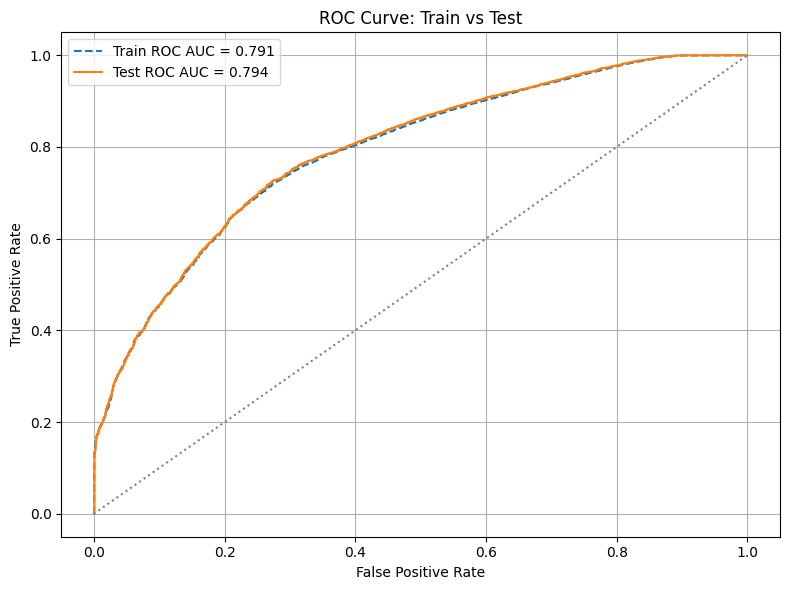

,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Train,0.736117,0.704739,0.490597,0.578486,0.791398
1,Test,0.734190,0.709987,0.494482,0.582956,0.794038


In [68]:
evaluate_model(log_reg_pca, X_train_pca, y_train, X_test_pca, y_test)